In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


In [ ]:
df = pd.read_csv('../data/makeup_sales_dataset_2025.csv')

In [ ]:
df.head()

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
0,1,2025-11-24,Fenty Beauty,Eyeliner,UAE,Retail Store,Digital Wallet,17.80,48,854.40
1,2,2025-02-22,L'Oreal,Highlighter,USA,Online,Cash,82.82,35,2898.70
2,3,2025-04-22,Maybelline,Eyeliner,Germany,Retail Store,Card,31.76,39,1238.64
3,4,2025-10-29,MAC,Highlighter,France,Mall,Cash,36.99,1,36.99
4,5,2025-04-21,L'Oreal,Lipstick,Germany,Online,Card,115.08,22,2531.76


In [ ]:
df.isna().sum()

Sale_ID           0
Date              0
Brand             0
Product_Type      0
Country           0
Sales_Channel     0
Payment_Method    0
Price_USD         0
Units_Sold        0
Revenue_USD       0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

Sale_ID             int64
Date                  str
Brand                 str
Product_Type          str
Country               str
Sales_Channel         str
Payment_Method        str
Price_USD         float64
Units_Sold          int64
Revenue_USD       float64
dtype: object

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], yearfirst=True, errors='raise')

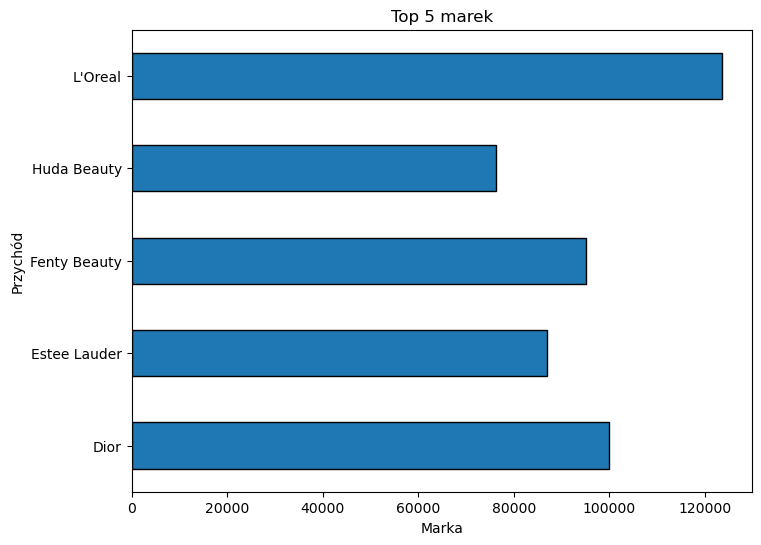

In [ ]:
plt.figure(figsize=(8,6))
ax = df.groupby(by='Brand')['Revenue_USD'].sum().head(5).plot(kind='barh', edgecolor = 'black')
plt.xlabel('Marka')
plt.ylabel('Przychód')
plt.title('Top 5 marek')
plt.savefig('../images/top_5_brands.png', dpi=300, bbox_inches='tight')
plt.show()

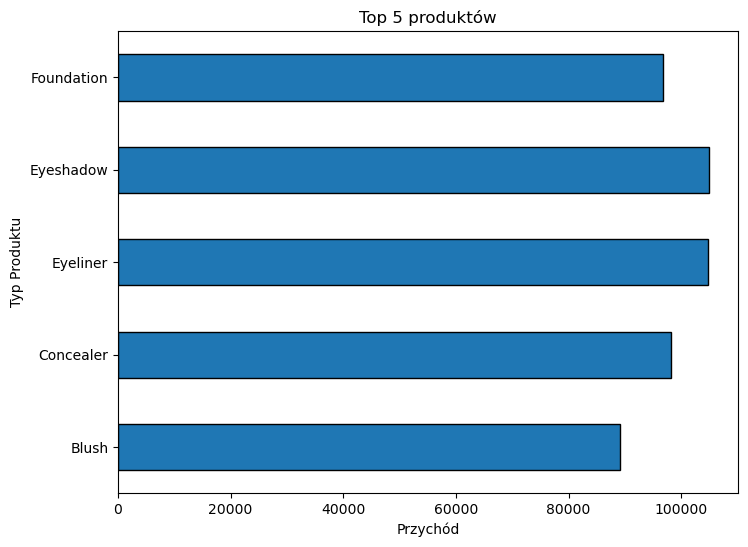

In [ ]:
plt.figure(figsize=(8,6))
ax = df.groupby(by= 'Product_Type')['Revenue_USD'].sum().head(5).plot(kind='barh', edgecolor = 'black')
plt.xlabel('Przychód')
plt.ylabel('Typ Produktu')
plt.title('Top 5 produktów')
plt.savefig('../images/top_5_products.png', dpi=300, bbox_inches='tight')
plt.show()

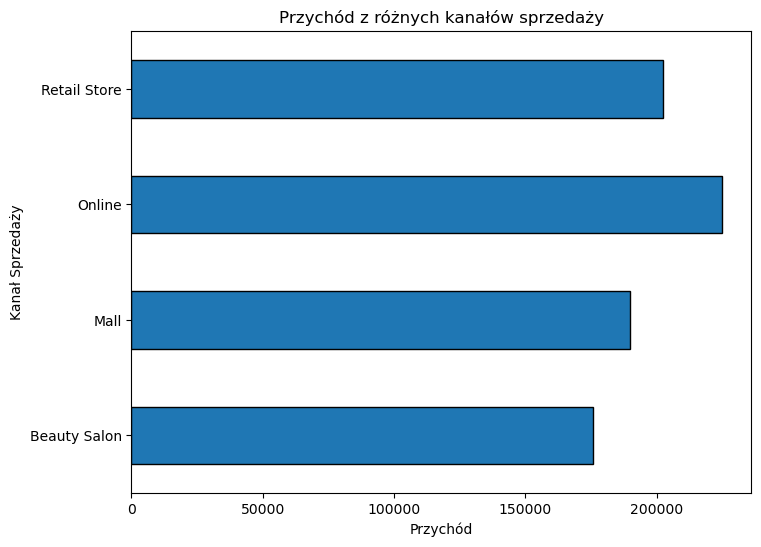

In [ ]:
plt.figure(figsize=(8,6))
ax = df.groupby(by= 'Sales_Channel')['Revenue_USD'].sum().plot(kind='barh', edgecolor = 'black')
plt.xlabel('Przychód')
plt.ylabel('Kanał Sprzedaży')
plt.title('Przychód z różnych kanałów sprzedaży')
plt.savefig('../images/sales_channels_revenue.png', dpi=300, bbox_inches='tight')
plt.show()

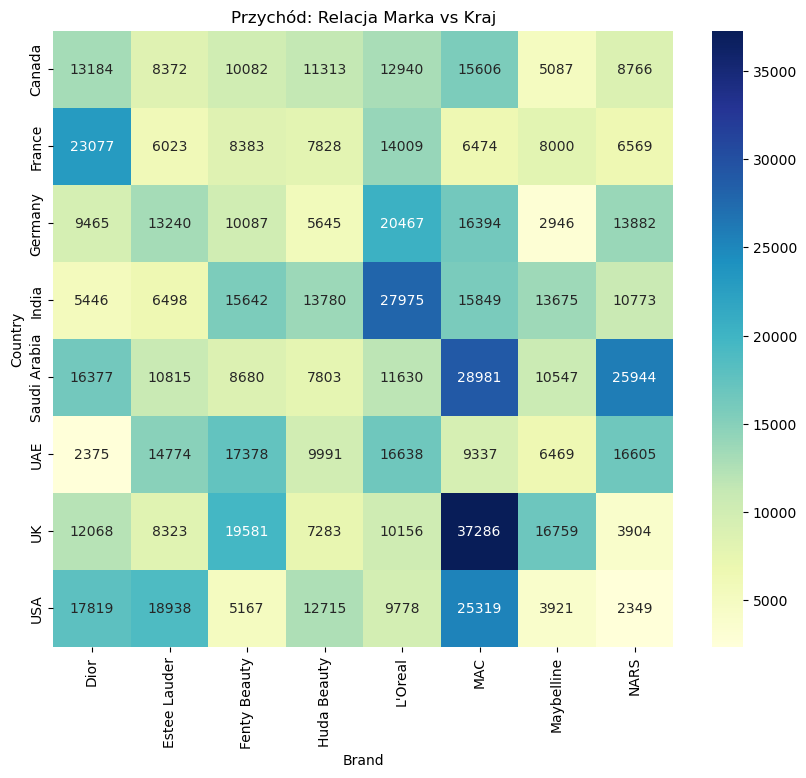

In [ ]:
ax = df.groupby(by = ['Country', 'Brand'])['Revenue_USD'].sum()
df_matrix = ax.unstack()
plt.figure(figsize=(10, 8))
sns.heatmap(data=df_matrix, annot=True, fmt=".0f", cmap='YlGnBu')
plt.title('Przychód: Relacja Marka vs Kraj')
plt.savefig('../images/heatmap_brand_country.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
df = df.set_index('Date')
df = df.sort_index()

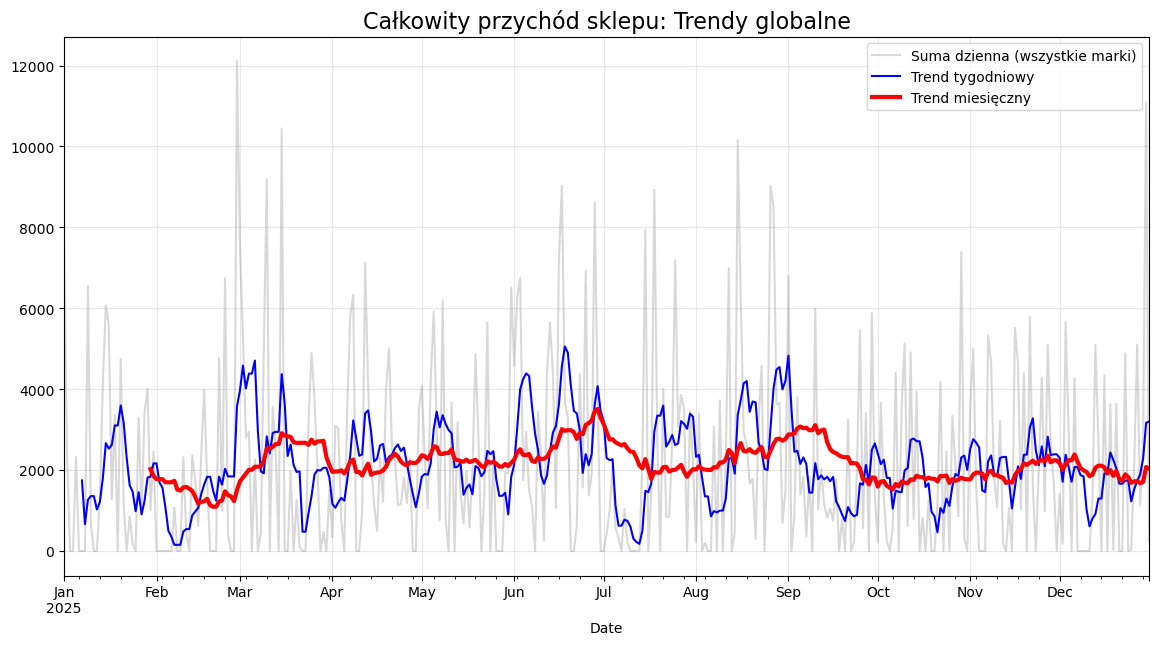

In [ ]:
# Sumujemy przychód ze wszystkich marek dla każdego dnia
daily_total = df['Revenue_USD'].resample('D').sum()

plt.figure(figsize=(14, 7))
daily_total.plot(alpha=0.3, color='gray', label='Suma dzienna (wszystkie marki)')
daily_total.rolling(window=7).mean().plot(color='blue', label='Trend tygodniowy')
daily_total.rolling(window=30).mean().plot(color='red', linewidth=3, label='Trend miesięczny')

plt.title('Całkowity przychód sklepu: Trendy globalne', fontsize=16)
plt.legend()
plt.grid(True, alpha = 0.3)
plt.savefig('../images/global_revenue_trend.png', dpi=300, bbox_inches='tight')
plt.show()

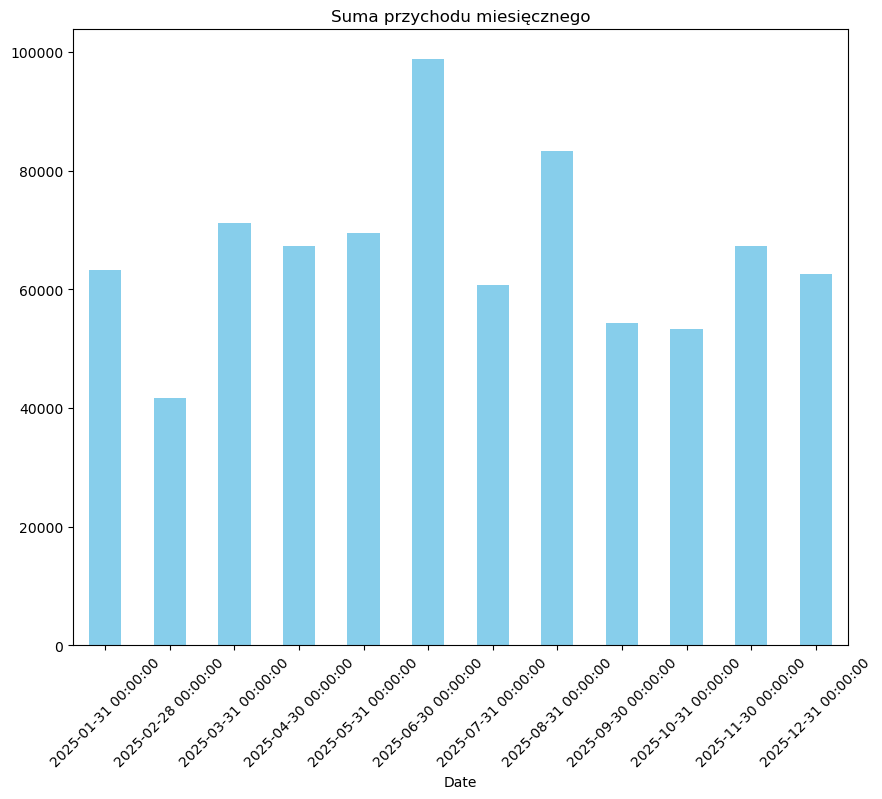

In [ ]:
monthly_revenue = df['Revenue_USD'].resample('ME').sum()

plt.figure(figsize=(10, 8))
monthly_revenue.plot(kind='bar', color='skyblue')
plt.title('Suma przychodu miesięcznego')
plt.xticks(rotation=45)
plt.savefig('../images/monthly_revenue_total.png', dpi=300, bbox_inches='tight')
plt.show()

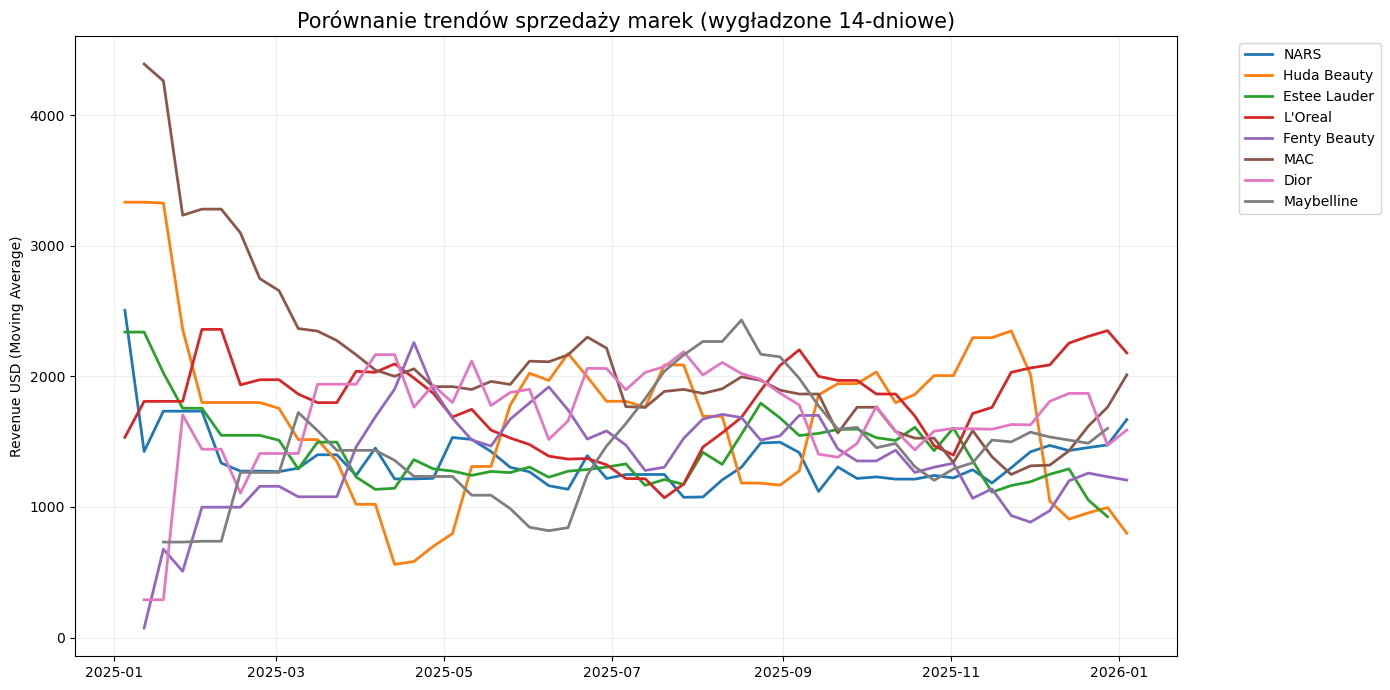

In [ ]:

plt.figure(figsize=(14, 7))

for brand in df['Brand'].unique():
    # Pobieramy dane dla marki i resamplujemy do dni
    brand_data = df[df['Brand'] == brand]['Revenue_USD'].resample('W').mean()
    # Obliczamy średnią kroczącą 
    brand_trend = brand_data.rolling(window=12, min_periods=1).mean()
    
    # Rysujemy wygładzoną linię
    plt.plot(brand_trend.index, brand_trend.values, label=brand, linewidth=2)

plt.title('Porównanie trendów sprzedaży marek (wygładzone 14-dniowe)', fontsize=15)
plt.ylabel('Revenue USD (Moving Average)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Legenda obok wykresu
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('../images/brand_trends_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
df.to_csv('../data/data_for_model.csv', index=True) 